# Model Validation Notebook

Offline validation of four pretrained CSGDB survival models.

**Dataset:** 122 patients — 25 recurrence events, 33 death events

**Models:**
- Recurrence RSF and Recurrence CoxPH (primary focus)
- Overall Survival RSF and Overall Survival CoxPH (secondary)

**Validation techniques:**
1. C-index — apparent and .632 bootstrap-corrected
2. Integrated Brier Score (IBS) — apparent and .632 bootstrap-corrected
3. Calibration intercept and slope — apparent and .632 bootstrap-corrected
4. Schoenfeld residuals — CoxPH models only (PH assumption diagnostic, not bootstrapped)

> **Note on calibration curves:** Per Van Calster et al. (2019), calibration curves require \u2265200 events.
> With 25\u201333 events, only weak calibration (intercept + slope) is reported.

In [2]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logit
from sklearn.linear_model import LogisticRegression
from sksurv.metrics import concordance_index_censored, brier_score, integrated_brier_score
from IPython.display import display as ipy_display

# Add python-ml-engine to sys.path — required to unpickle FeatureExtractor from .joblib files
ENGINE_PATH = Path('../python-ml-engine').resolve()
if str(ENGINE_PATH) not in sys.path:
    sys.path.insert(0, str(ENGINE_PATH))

from feature_extractor import FeatureExtractor
from survival_model import SurvivalModel

np.random.seed(42)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('colorblind')

DATA_PATH   = Path('data/patients.json')
MODELS_PATH = Path('../pretrained-models')
CAL_T_STAR  = 365  # 1-year calibration time point (days)

print('Setup complete.')

Setup complete.


## 1. Load Data and Models

In [3]:
with open(DATA_PATH) as f:
    patients = json.load(f)
print(f'Loaded {len(patients)} patients\n')

MODEL_FILES = {
    'recurrence_rsf':   MODELS_PATH / 'recurrence_rsf_2026-04-15T14-02-44-446Z.joblib',
    'recurrence_coxph': MODELS_PATH / 'recurrence_coxph_2026-04-15T14-04-31-450Z.joblib',
    'survival_rsf':     MODELS_PATH / 'overall_survival_rsf_2026-04-15T14-08-29-926Z.joblib',
    'survival_coxph':   MODELS_PATH / 'overall_survival_coxph_2026-04-15T14-09-56-119Z.joblib',
}

models = {}
for name, path in MODEL_FILES.items():
    model, extractor, metadata = SurvivalModel.load(str(path))
    models[name] = {'model': model, 'extractor': extractor, 'metadata': metadata}
    n_s   = metadata['n_samples']
    n_ev  = metadata['n_events']
    c_app = metadata['c_index']
    c_632 = metadata['bootstrap_c_index']
    c_std = metadata['bootstrap_c_index_std']
    c_nv  = metadata['bootstrap_n_valid']
    print('-' * 55)
    print(f'  {name}')
    print(f'  n_samples={n_s}  n_events={n_ev}')
    print(f'  C-index (apparent):    {c_app:.4f}')
    print(f'  C-index (.632 boot):   {c_632:.4f} +/- {c_std:.4f}  ({c_nv} valid iters)')

Loaded 122 patients

-------------------------------------------------------
  recurrence_rsf
  n_samples=122  n_events=25
  C-index (apparent):    0.8708
  C-index (.632 boot):   0.8139 +/- 0.0668  (200 valid iters)
-------------------------------------------------------
  recurrence_coxph
  n_samples=122  n_events=25
  C-index (apparent):    0.8353
  C-index (.632 boot):   0.7826 +/- 0.0871  (200 valid iters)
-------------------------------------------------------
  survival_rsf
  n_samples=122  n_events=33
  C-index (apparent):    0.8173
  C-index (.632 boot):   0.7607 +/- 0.0606  (200 valid iters)
-------------------------------------------------------
  survival_coxph
  n_samples=122  n_events=33
  C-index (apparent):    0.7617
  C-index (.632 boot):   0.7246 +/- 0.0752  (200 valid iters)


## 2. Helper Functions

In [4]:
def prepare_data(patients, model_type, extractor):
    """Transform raw patients into X, y_event, y_time, y_struct using a fitted extractor."""
    X = extractor.transform(patients)
    df = extractor._apply_stage_fallback(pd.DataFrame(patients))
    y_ev, y_t = extractor.extract_targets(df, model_type)
    valid = ~np.isnan(y_t)
    X    = X[valid]
    y_ev = y_ev[valid]
    y_t  = y_t[valid]
    y_struct = np.array(
        [(bool(e), float(t)) for e, t in zip(y_ev, y_t)],
        dtype=[('event', bool), ('time', float)]
    )
    return X, y_ev, y_t, y_struct


def predict_survival_matrix(model_obj, X, times):
    """Return survival probability matrix of shape (n_samples, n_times)."""
    surv_funcs = model_obj.model.predict_survival_function(X)
    out = np.zeros((len(X), len(times)))
    for i, sf in enumerate(surv_funcs):
        for j, t in enumerate(times):
            out[i, j] = float(sf(t)) if t <= sf.x[-1] else float(sf.y[-1])
    return out


def calibration_at_t(model_obj, X, y_event, y_time, t_star):
    """
    Weak calibration intercept and slope at t_star days.

    Approach:
      - Predicted event probability = 1 - S(t*)
      - Observed binary outcome: event occurred by t* (1) or event-free at t* (0)
      - Patients censored before t* are excluded (outcome unknown)
      - Logistic regression: observed ~ logit(predicted) -> intercept and slope
      Target values: intercept = 0, slope = 1

    Returns (intercept, slope, n_included). Returns (nan, nan, n) if n_included < 10.
    """
    surv_funcs = model_obj.model.predict_survival_function(X)
    pred_surv = np.array([
        float(sf(t_star)) if t_star <= sf.x[-1] else float(sf.y[-1])
        for sf in surv_funcs
    ])
    pred_prob = 1.0 - pred_surv

    obs   = ((y_event == 1) & (y_time <= t_star)).astype(int)
    known = ~((y_event == 0) & (y_time < t_star))  # exclude censored before t*

    n_inc = int(known.sum())
    if n_inc < 10:
        return np.nan, np.nan, n_inc

    pp = np.clip(pred_prob[known], 1e-6, 1 - 1e-6)
    oo = obs[known]
    if oo.sum() == 0 or oo.sum() == n_inc:  # degenerate: all same outcome
        return np.nan, np.nan, n_inc

    lo = logit(pp).reshape(-1, 1)
    lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    lr.fit(lo, oo)
    return float(lr.intercept_[0]), float(lr.coef_[0][0]), n_inc


def apparent_metrics(model_obj, X, y_struct, y_event, y_time, eval_times, cal_t_star=CAL_T_STAR):
    """Compute all apparent (full-dataset) metrics for one model."""
    # C-index
    risk  = model_obj.model.predict(X)
    c_idx = float(concordance_index_censored(y_struct['event'], y_struct['time'], risk)[0])

    # Brier score curve + IBS (clip eval_times to the valid event time range)
    ev_t = y_struct['time'][y_struct['event']]
    t_lo = float(ev_t.min()) + 0.1
    t_hi = float(ev_t.max()) - 0.1
    vt   = eval_times[(eval_times >= t_lo) & (eval_times <= t_hi)]

    if len(vt) >= 2:
        sm = predict_survival_matrix(model_obj, X, vt)
        try:
            _, bs_curve = brier_score(y_struct, y_struct, sm, vt)
            ibs_val     = float(integrated_brier_score(y_struct, y_struct, sm, vt))
        except Exception:
            bs_curve = np.full(len(vt), np.nan)
            ibs_val  = np.nan
    else:
        bs_curve = np.array([])
        ibs_val  = np.nan
        vt       = np.array([])

    # Calibration
    cal_int, cal_sl, n_cal = calibration_at_t(model_obj, X, y_event, y_time, cal_t_star)

    return {
        'c_index':       c_idx,
        'ibs':           ibs_val,
        'bs_curve':      bs_curve,
        'bs_times':      vt,
        'cal_intercept': cal_int,
        'cal_slope':     cal_sl,
        'n_cal':         n_cal,
    }


def bootstrap_master_loop(
    patients, model_type, algorithm, apparent,
    eval_times, cal_t_star=CAL_T_STAR, n_bootstrap=200, random_state=42
):
    """
    Single-loop .632 bootstrap computing C-index, IBS, and calibration in one pass.

    Each iteration:
      1. Draw N patients with replacement (bootstrap sample).
      2. OOB patients = those never drawn (~36.8% of unique patients).
      3. Fit fresh FeatureExtractor + SurvivalModel on bootstrap sample.
      4. Evaluate all metrics on OOB patients.

    .632 correction: metric_632 = 0.368 * metric_apparent + 0.632 * mean(metric_OOB)
    """
    rng = np.random.default_rng(random_state)
    n   = len(patients)
    oob_c, oob_ibs, oob_ci, oob_cs = [], [], [], []
    skipped = 0

    for it in range(n_bootstrap):
        boot_idx = rng.integers(0, n, size=n)
        oob_idx  = np.setdiff1d(np.arange(n), boot_idx)

        if len(oob_idx) < 5:
            skipped += 1
            continue

        boot_pts = [patients[i] for i in boot_idx]
        oob_pts  = [patients[i] for i in oob_idx]

        try:
            # Fit fresh extractor + model on bootstrap sample only
            ext = FeatureExtractor()
            X_b, ev_b, t_b, _ = ext.fit_transform(boot_pts, model_type)
            if sum(ev_b) < 2:
                skipped += 1
                continue

            mdl = SurvivalModel(algorithm=algorithm)
            mdl.fit(X_b, ev_b, t_b)

            y_b = np.array(
                [(bool(e), float(t)) for e, t in zip(ev_b, t_b)],
                dtype=[('event', bool), ('time', float)]
            )

            # Transform OOB patients with bootstrap-fitted extractor
            X_o       = ext.transform(oob_pts)
            df_o      = ext._apply_stage_fallback(pd.DataFrame(oob_pts))
            ev_o, t_o = ext.extract_targets(df_o, model_type)
            valid     = ~np.isnan(t_o)
            if valid.sum() < 5 or sum(ev_o[valid]) < 2:
                skipped += 1
                continue

            X_o  = X_o[valid];  ev_o = ev_o[valid];  t_o = t_o[valid]
            y_o  = np.array(
                [(bool(e), float(t)) for e, t in zip(ev_o, t_o)],
                dtype=[('event', bool), ('time', float)]
            )

            # C-index on OOB
            risk_o = mdl.model.predict(X_o)
            oob_c.append(float(concordance_index_censored(y_o['event'], y_o['time'], risk_o)[0]))

            # IBS on OOB (y_b used for IPCW censoring distribution)
            ev_t_o = y_o['time'][y_o['event']]
            if len(ev_t_o) >= 2:
                vt = eval_times[
                    (eval_times >= ev_t_o.min() + 0.1) &
                    (eval_times <= ev_t_o.max() - 0.1)
                ]
                if len(vt) >= 2:
                    sm_o = predict_survival_matrix(mdl, X_o, vt)
                    try:
                        oob_ibs.append(float(integrated_brier_score(y_b, y_o, sm_o, vt)))
                    except Exception:
                        pass

            # Calibration on OOB
            ci, cs, _ = calibration_at_t(mdl, X_o, ev_o, t_o, cal_t_star)
            if not np.isnan(ci):
                oob_ci.append(ci)
                oob_cs.append(cs)

        except Exception:
            skipped += 1
            continue

    n_c, n_ibs, n_cal = len(oob_c), len(oob_ibs), len(oob_ci)
    print(f'  Skipped {skipped}/{n_bootstrap}  |  Valid: C={n_c}, IBS={n_ibs}, Cal={n_cal}')

    def _c632(app, oob):
        if not oob or (isinstance(app, float) and np.isnan(app)):
            return (float(app) if app is not None else np.nan), np.nan
        return float(0.368 * app + 0.632 * float(np.mean(oob))), float(np.std(oob))

    c_v,  c_s  = _c632(apparent['c_index'],       oob_c)
    i_v,  i_s  = _c632(apparent['ibs'],           oob_ibs)
    ci_v, ci_s = _c632(apparent['cal_intercept'], oob_ci)
    cs_v, cs_s = _c632(apparent['cal_slope'],     oob_cs)

    return {
        'c_index_632':       c_v,   'c_index_std':        c_s,
        'ibs_632':           i_v,   'ibs_std':            i_s,
        'cal_intercept_632': ci_v,  'cal_intercept_std':  ci_s,
        'cal_slope_632':     cs_v,  'cal_slope_std':      cs_s,
        'n_valid_c':   n_c,
        'n_valid_ibs': n_ibs,
        'n_valid_cal': n_cal,
    }


def _fmt(v, s=None):
    """Format a metric value with optional standard deviation."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return 'N/A'
    if s is not None and not (isinstance(s, float) and np.isnan(s)):
        return f'{v:.4f} +/- {s:.4f}'
    return f'{v:.4f}'


def display_results(label, app_rsf, boot_rsf, app_coxph, boot_coxph, cal_label):
    """Print a comparison table of apparent vs .632 bootstrap metrics for RSF and CoxPH."""
    rows = [
        ['C-index',
         _fmt(app_rsf['c_index']),
         _fmt(boot_rsf['c_index_632'], boot_rsf['c_index_std']),
         _fmt(app_coxph['c_index']),
         _fmt(boot_coxph['c_index_632'], boot_coxph['c_index_std'])],
        ['IBS',
         _fmt(app_rsf['ibs']),
         _fmt(boot_rsf['ibs_632'], boot_rsf['ibs_std']),
         _fmt(app_coxph['ibs']),
         _fmt(boot_coxph['ibs_632'], boot_coxph['ibs_std'])],
        [f'Cal. Intercept ({cal_label})',
         _fmt(app_rsf['cal_intercept']),
         _fmt(boot_rsf['cal_intercept_632'], boot_rsf['cal_intercept_std']),
         _fmt(app_coxph['cal_intercept']),
         _fmt(boot_coxph['cal_intercept_632'], boot_coxph['cal_intercept_std'])],
        [f'Cal. Slope ({cal_label})',
         _fmt(app_rsf['cal_slope']),
         _fmt(boot_rsf['cal_slope_632'], boot_rsf['cal_slope_std']),
         _fmt(app_coxph['cal_slope']),
         _fmt(boot_coxph['cal_slope_632'], boot_coxph['cal_slope_std'])],
    ]
    df_t = pd.DataFrame(rows, columns=[
        'Metric', 'RSF Apparent', 'RSF .632 Boot', 'CoxPH Apparent', 'CoxPH .632 Boot'
    ]).set_index('Metric')
    print('=' * 65)
    print(f'  {label}  |  Calibration at {cal_label}')
    print( '  Target values: Cal. Intercept = 0  |  Cal. Slope = 1')
    print('=' * 65)
    ipy_display(df_t)
    return df_t


def plot_brier_curves(app_rsf, app_coxph, title):
    """Plot apparent Brier score curves for RSF and CoxPH on the same axes."""
    fig, ax = plt.subplots(figsize=(8, 5))
    if len(app_rsf['bs_times']) > 0 and not np.all(np.isnan(app_rsf['bs_curve'])):
        ax.plot(app_rsf['bs_times'] / 365.25, app_rsf['bs_curve'],
                label='RSF', linewidth=2)
    if len(app_coxph['bs_times']) > 0 and not np.all(np.isnan(app_coxph['bs_curve'])):
        ax.plot(app_coxph['bs_times'] / 365.25, app_coxph['bs_curve'],
                label='CoxPH', linewidth=2, linestyle='--')
    ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5, label='Null model (BS=0.25)')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Brier Score')
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    ax.legend()
    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


## 3. Recurrence Models (Primary)

In [5]:
print('=' * 55)
print('RECURRENCE  —  Random Survival Forest')
print('=' * 55)

m_rsf    = models['recurrence_rsf']['model']
ext_rsf  = models['recurrence_rsf']['extractor']
alg_rsf  = m_rsf.algorithm

X_rr, ev_rr, t_rr, ys_rr = prepare_data(patients, 'recurrence', ext_rsf)
ev_t_rr   = t_rr[ev_rr == 1]
eval_t_rr = np.linspace(ev_t_rr.min() + 1, ev_t_rr.max() - 1, 80)

n_rr  = len(X_rr)
nev_rr = int(ev_rr.sum())
print(f'Dataset: n={n_rr}, events={nev_rr}')

app_rr = apparent_metrics(m_rsf, X_rr, ys_rr, ev_rr, t_rr, eval_t_rr)
print(f'Apparent: C={app_rr["c_index"]:.4f}, IBS={app_rr["ibs"]:.4f}, n_cal={app_rr["n_cal"]}')

print('\nRunning bootstrap (.632, 200 iterations) ...')
boot_rr = bootstrap_master_loop(patients, 'recurrence', alg_rsf, app_rr, eval_t_rr)
print(f'Bootstrap .632: C={boot_rr["c_index_632"]:.4f} +/- {boot_rr["c_index_std"]:.4f}')

RECURRENCE  —  Random Survival Forest
Dataset: n=119, events=25
Apparent: C=0.8708, IBS=0.0858, n_cal=90

Running bootstrap (.632, 200 iterations) ...


[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 4 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 6 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 5 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureEx

  Skipped 0/200  |  Valid: C=200, IBS=198, Cal=200
Bootstrap .632: C=0.8139 +/- 0.0668


In [6]:
print('=' * 55)
print('RECURRENCE  —  Cox Proportional Hazards')
print('=' * 55)

m_rc    = models['recurrence_coxph']['model']
ext_rc  = models['recurrence_coxph']['extractor']
alg_rc  = m_rc.algorithm

X_rc, ev_rc, t_rc, ys_rc = prepare_data(patients, 'recurrence', ext_rc)
ev_t_rc   = t_rc[ev_rc == 1]
eval_t_rc = np.linspace(ev_t_rc.min() + 1, ev_t_rc.max() - 1, 80)

print(f'Dataset: n={len(X_rc)}, events={int(ev_rc.sum())}')

app_rc = apparent_metrics(m_rc, X_rc, ys_rc, ev_rc, t_rc, eval_t_rc)
print(f'Apparent: C={app_rc["c_index"]:.4f}, IBS={app_rc["ibs"]:.4f}, n_cal={app_rc["n_cal"]}')

print('\nRunning bootstrap (.632, 200 iterations) ...')
boot_rc = bootstrap_master_loop(patients, 'recurrence', alg_rc, app_rc, eval_t_rc)
print(f'Bootstrap .632: C={boot_rc["c_index_632"]:.4f} +/- {boot_rc["c_index_std"]:.4f}')

[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.


RECURRENCE  —  Cox Proportional Hazards
Dataset: n=119, events=25
Apparent: C=0.8353, IBS=0.1069, n_cal=90

Running bootstrap (.632, 200 iterations) ...


[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 4 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 6 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 5 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 7 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureEx

  Skipped 0/200  |  Valid: C=200, IBS=198, Cal=200
Bootstrap .632: C=0.7826 +/- 0.0871


  Recurrence Models  |  Calibration at 365d (1.0yr)
  Target values: Cal. Intercept = 0  |  Cal. Slope = 1


,RSF Apparent,RSF .632 Boot,CoxPH Apparent,CoxPH .632 Boot
Metric,,,,
C-index,0.8708,0.8139 +/- 0.0668,0.8353,0.7826 +/- 0.0871
IBS,0.0858,0.1149 +/- 0.0441,0.1069,0.1365 +/- 0.0633
Cal. Intercept (365d (1.0yr)),1.3607,0.5028 +/- 0.9633,-0.0687,-0.4106 +/- 1.1816
Cal. Slope (365d (1.0yr)),2.2932,1.4846 +/- 0.5626,0.8253,0.6385 +/- 0.4872


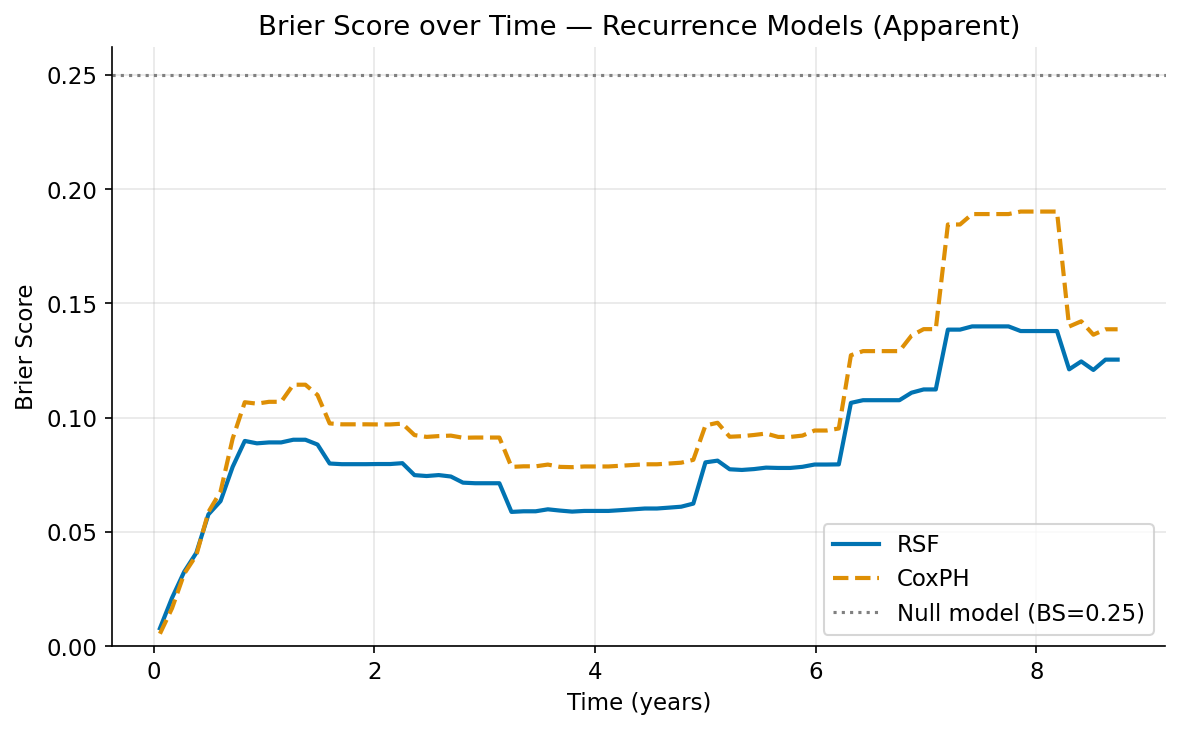

In [7]:
cal_label = f'{CAL_T_STAR}d ({CAL_T_STAR / 365.25:.1f}yr)'
display_results('Recurrence Models', app_rr, boot_rr, app_rc, boot_rc, cal_label)
plot_brier_curves(app_rr, app_rc, 'Brier Score over Time — Recurrence Models (Apparent)')

## 4. Overall Survival Models (Secondary)

In [8]:
print('=' * 55)
print('OVERALL SURVIVAL  —  Random Survival Forest')
print('=' * 55)

m_srsf    = models['survival_rsf']['model']
ext_srsf  = models['survival_rsf']['extractor']
alg_srsf  = m_srsf.algorithm

X_sr, ev_sr, t_sr, ys_sr = prepare_data(patients, 'overall_survival', ext_srsf)
ev_t_sr   = t_sr[ev_sr == 1]
eval_t_sr = np.linspace(ev_t_sr.min() + 1, ev_t_sr.max() - 1, 80)

print(f'Dataset: n={len(X_sr)}, events={int(ev_sr.sum())}')

app_sr = apparent_metrics(m_srsf, X_sr, ys_sr, ev_sr, t_sr, eval_t_sr)
print(f'Apparent: C={app_sr["c_index"]:.4f}, IBS={app_sr["ibs"]:.4f}, n_cal={app_sr["n_cal"]}')

print('\nRunning bootstrap (.632, 200 iterations) ...')
boot_sr = bootstrap_master_loop(patients, 'overall_survival', alg_srsf, app_sr, eval_t_sr)
print(f'Bootstrap .632: C={boot_sr["c_index_632"]:.4f} +/- {boot_sr["c_index_std"]:.4f}')

[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.


OVERALL SURVIVAL  —  Random Survival Forest
Dataset: n=119, events=33
Apparent: C=0.8173, IBS=0.1119, n_cal=102

Running bootstrap (.632, 200 iterations) ...


[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 4 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 6 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 5 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureEx

  Skipped 0/200  |  Valid: C=200, IBS=178, Cal=183
Bootstrap .632: C=0.7607 +/- 0.0606


In [9]:
print('=' * 55)
print('OVERALL SURVIVAL  —  Cox Proportional Hazards')
print('=' * 55)

m_sc    = models['survival_coxph']['model']
ext_sc  = models['survival_coxph']['extractor']
alg_sc  = m_sc.algorithm

X_sc, ev_sc, t_sc, ys_sc = prepare_data(patients, 'overall_survival', ext_sc)
ev_t_sc   = t_sc[ev_sc == 1]
eval_t_sc = np.linspace(ev_t_sc.min() + 1, ev_t_sc.max() - 1, 80)

print(f'Dataset: n={len(X_sc)}, events={int(ev_sc.sum())}')

app_sc = apparent_metrics(m_sc, X_sc, ys_sc, ev_sc, t_sc, eval_t_sc)
print(f'Apparent: C={app_sc["c_index"]:.4f}, IBS={app_sc["ibs"]:.4f}, n_cal={app_sc["n_cal"]}')

print('\nRunning bootstrap (.632, 200 iterations) ...')
boot_sc = bootstrap_master_loop(patients, 'overall_survival', alg_sc, app_sc, eval_t_sc)
print(f'Bootstrap .632: C={boot_sc["c_index_632"]:.4f} +/- {boot_sc["c_index_std"]:.4f}')

[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.


OVERALL SURVIVAL  —  Cox Proportional Hazards
Dataset: n=119, events=33
Apparent: C=0.7617, IBS=0.1326, n_cal=102

Running bootstrap (.632, 200 iterations) ...


[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 4 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 3 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 6 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 5 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 7 patient(s) with unresolvable follow-up time from training.
[FeatureExtractor] Excluding 1 patient(s) with unresolvable follow-up time from training.
[FeatureEx

  Skipped 0/200  |  Valid: C=200, IBS=178, Cal=183
Bootstrap .632: C=0.7246 +/- 0.0752


  Overall Survival Models  |  Calibration at 365d (1.0yr)
  Target values: Cal. Intercept = 0  |  Cal. Slope = 1


,RSF Apparent,RSF .632 Boot,CoxPH Apparent,CoxPH .632 Boot
Metric,,,,
C-index,0.8173,0.7607 +/- 0.0606,0.7617,0.7246 +/- 0.0752
IBS,0.1119,0.1535 +/- 0.0539,0.1326,0.1688 +/- 0.0608
Cal. Intercept (365d (1.0yr)),43.8532,16.4838 +/- 6.8130,-1.4244,-2.7345 +/- 31.8956
Cal. Slope (365d (1.0yr)),23.0549,9.3906 +/- 3.9822,0.4600,0.6463 +/- 11.1047


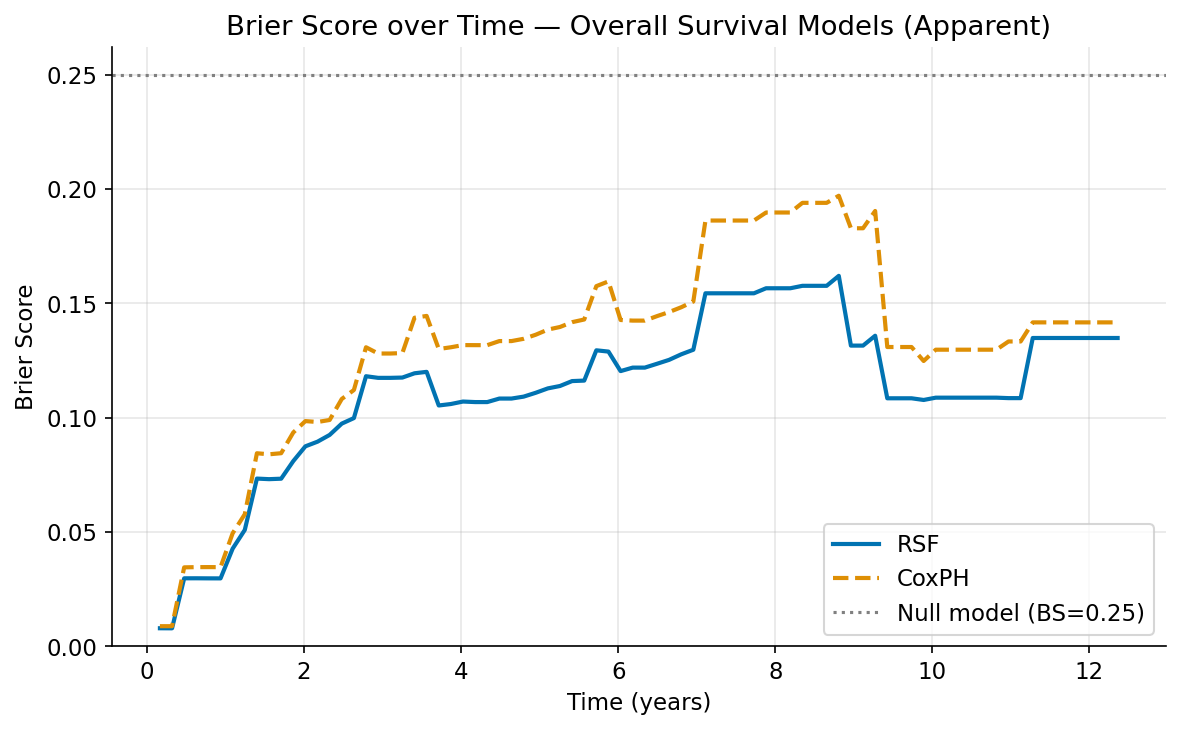

In [10]:
display_results('Overall Survival Models', app_sr, boot_sr, app_sc, boot_sc, cal_label)
plot_brier_curves(app_sr, app_sc, 'Brier Score over Time — Overall Survival Models (Apparent)')

## 5. CoxPH Proportional Hazards Assumption (Schoenfeld Residuals)

The Cox Proportional Hazards model assumes that the hazard ratio between any two subjects is constant over time.
This is tested using Schoenfeld residuals via `lifelines.CoxPHFitter.check_assumptions()`.

- A non-significant p-value (p ≥ 0.05) indicates the PH assumption holds for that predictor.
- A significant p-value (p < 0.05) indicates a violation — the predictor's effect changes over time.
- **Note:** lifelines CoxPH is fitted here solely for the diagnostic test. It is not the production model
  (which uses `scikit-survival.CoxPHSurvivalAnalysis`). Both use L2 regularization (penalizer=0.1).

Schoenfeld Residuals  —  Recurrence CoxPH
n=119, events=25
Fitting lifelines CoxPH ...

Model summary (diagnostic fit):


<lifelines.CoxPHFitter: fitted with 119 total observations, 94 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 119
number of events observed = 25
   partial log-likelihood = -85.96
         time fit was run = 2026-04-15 18:05:49 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
age_at_diagnosis      0.05      1.05      0.20           -0.34            0.43                0.71                1.54
positive_node_count   0.31      1.36      0.17           -0.02            0.64                0.98                1.90
t_stage               0.13      1.14      0.21           -0.28            0.54                0.76                1.71
grade                 0.15      1.16      0.23           -0.30            0.60                0.74                1.82
lymphatic_invasion    0.46      1.59      0.19            0.10            0.83                1.10                2.28
perineural_invasion   0.22      1.25      0.19           -0.15            0.60                0.86                1.82
extranodal_extension -0.02      0.98      0.17           -0.34            0.31                0.71                1.36

                      cmp to     z    p  -log2(p)
covariate                                        
age_at_diagnosis        0.00  0.23 0.82      0.29
positive_node_count     0.00  1.81 0.07      3.84
t_stage                 0.00  0.63 0.53      0.92
grade                   0.00  0.64 0.52      0.95
lymphatic_invasion      0.00  2.48 0.01      6.25
perineural_invasion     0.00  1.17 0.24      2.05
extranodal_extension    0.00 -0.10 0.92      0.11
---
Concordance = 0.83
Partial AIC = 185.92
log-likelihood ratio test = 32.01 on 7 df
-log2(p) of ll-ratio test = 14.59


PH assumption test (Schoenfeld residuals):
p < 0.05 = PH assumption violated for that predictor.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.3513)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4508)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3393)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4797)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7556)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8476)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7288)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8471)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5594)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6201)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5960)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4363)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4655)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5167)'>]]

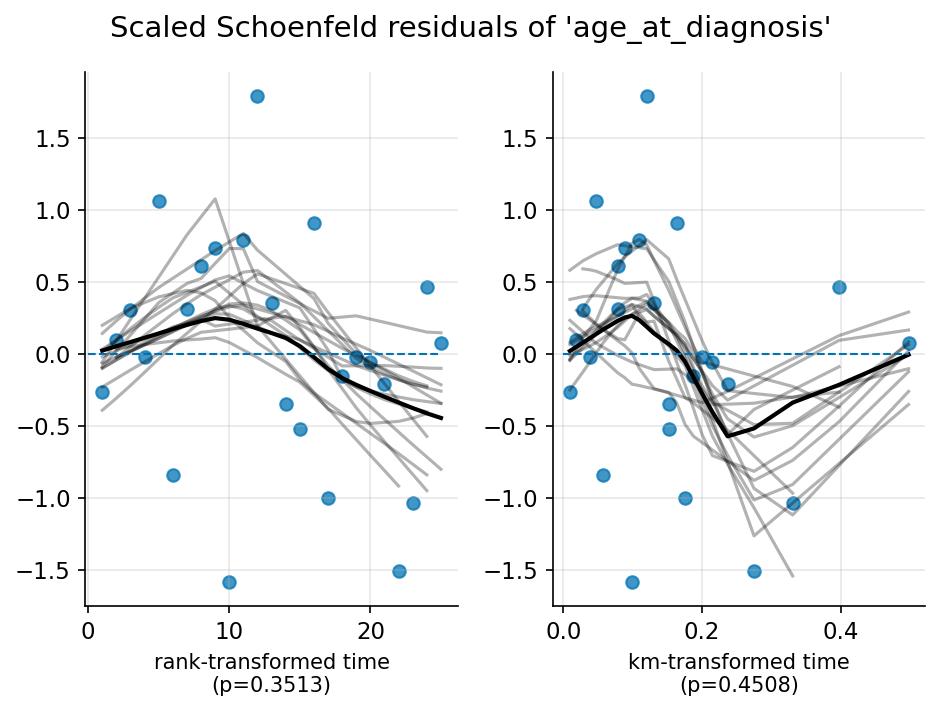

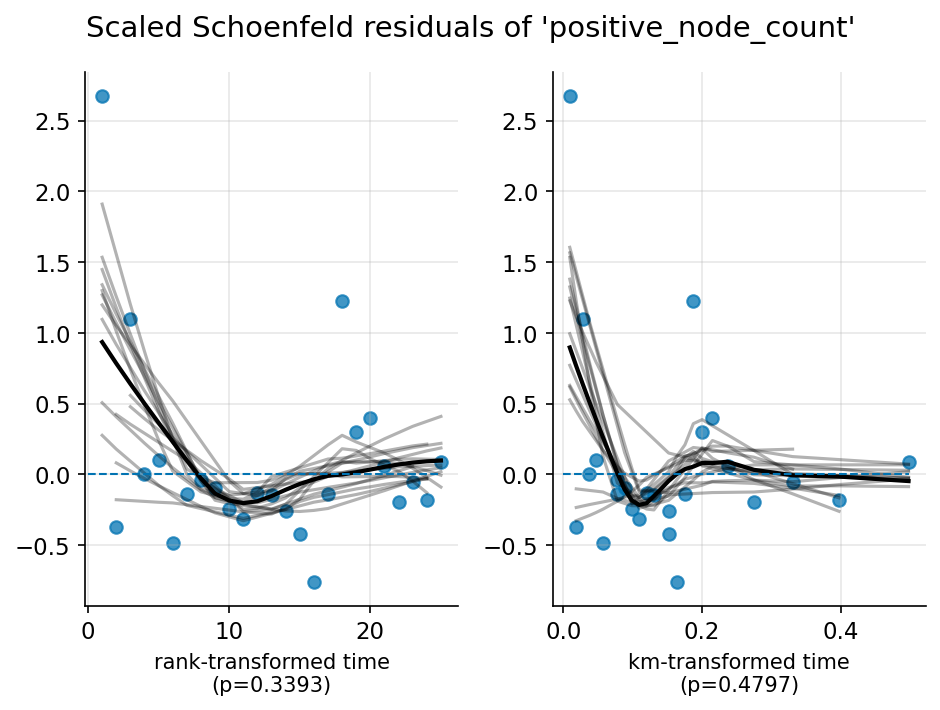

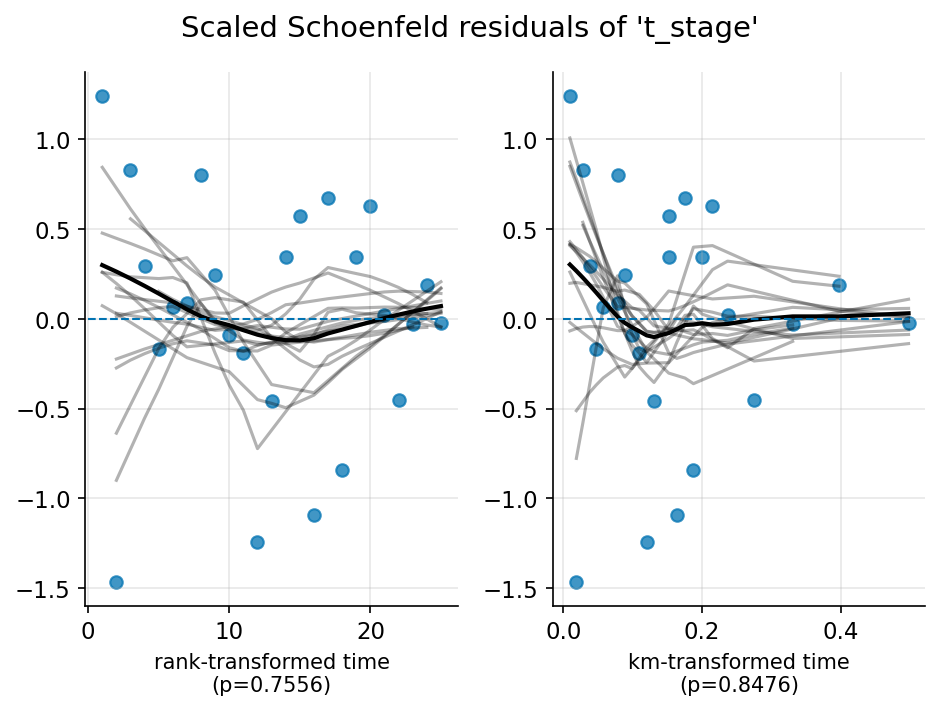

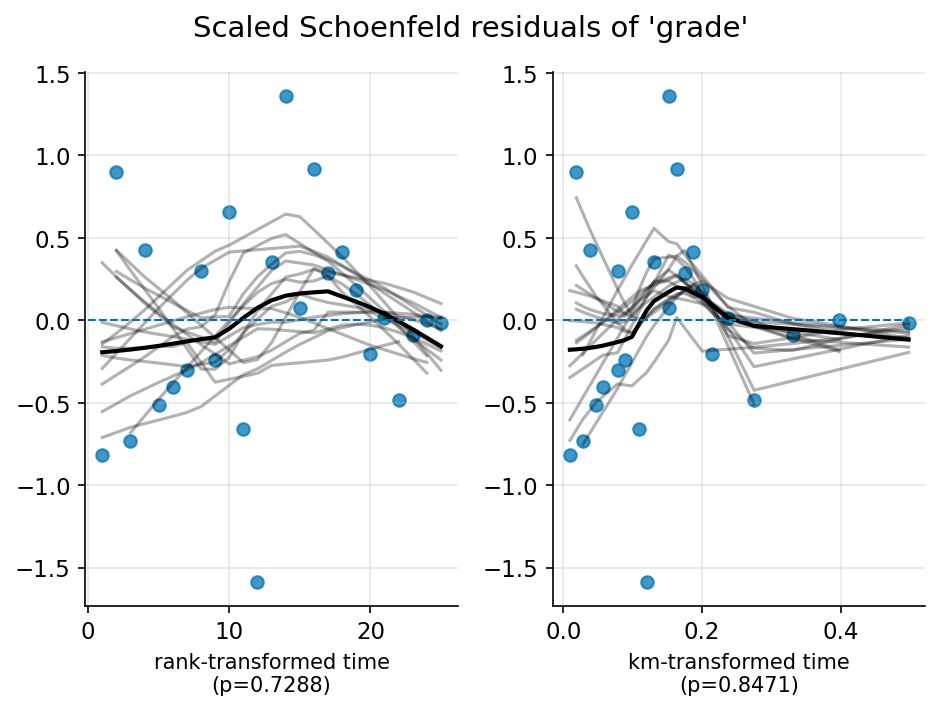

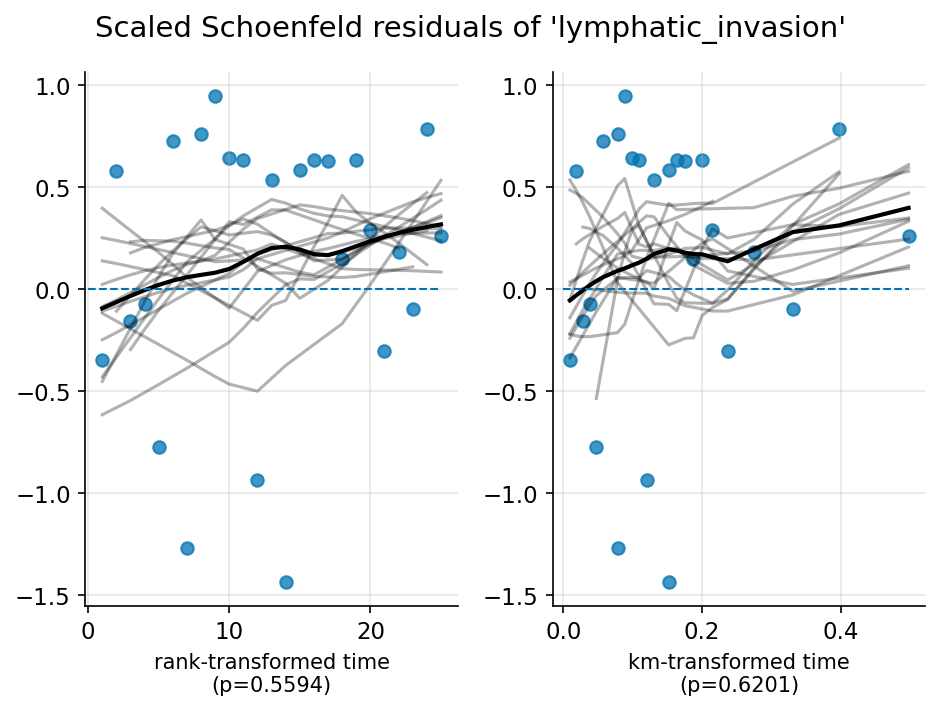

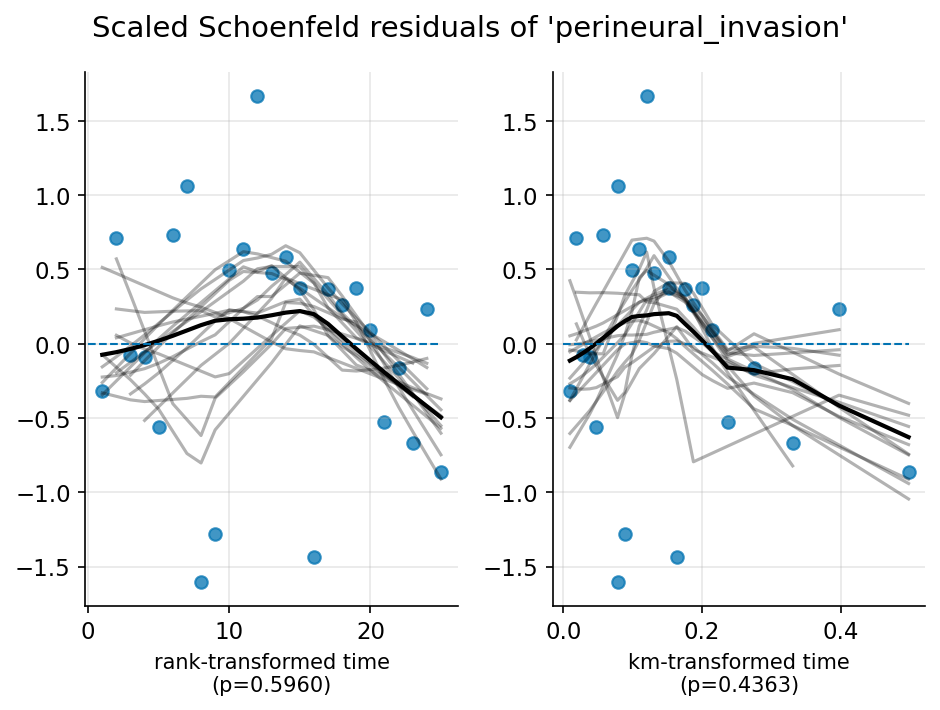

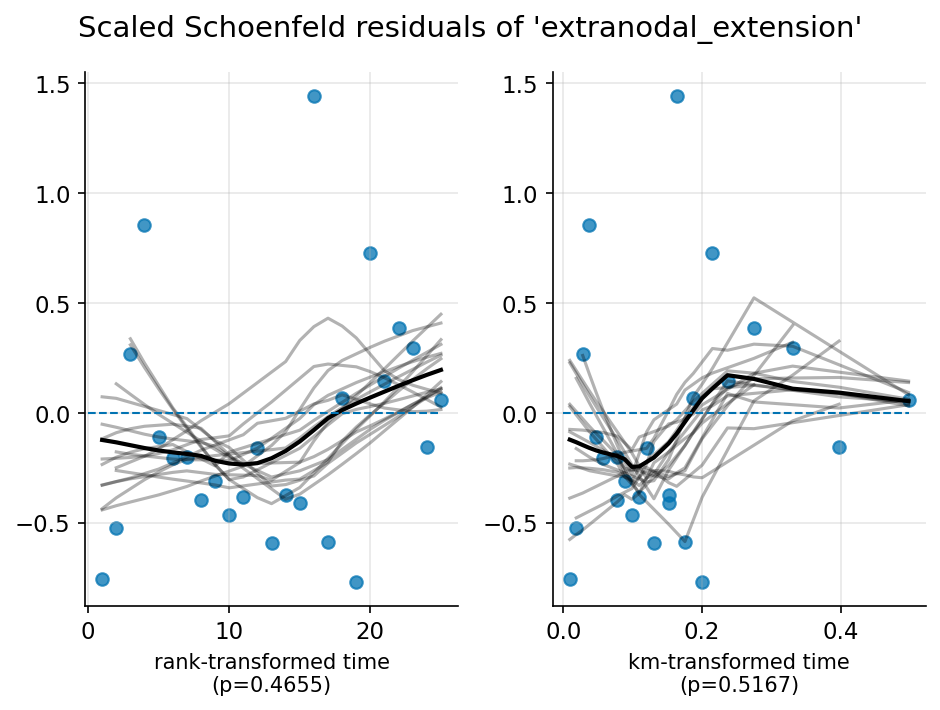

In [11]:
from lifelines import CoxPHFitter

print('=' * 55)
print('Schoenfeld Residuals  —  Recurrence CoxPH')
print('=' * 55)

X_sr_d, ev_sr_d, t_sr_d, _ = prepare_data(
    patients, 'recurrence', models['recurrence_coxph']['extractor']
)
feat_names_r = models['recurrence_coxph']['metadata']['feature_names']

df_sr_d = pd.DataFrame(X_sr_d, columns=feat_names_r)
df_sr_d['duration'] = t_sr_d
df_sr_d['event']    = ev_sr_d.astype(int)

print(f'n={len(df_sr_d)}, events={int(ev_sr_d.sum())}')
print('Fitting lifelines CoxPH ...')
cph_r = CoxPHFitter(penalizer=0.1)
cph_r.fit(df_sr_d, duration_col='duration', event_col='event')

print('\nModel summary (diagnostic fit):')
cph_r.print_summary()

print('\nPH assumption test (Schoenfeld residuals):')
print('p < 0.05 = PH assumption violated for that predictor.\n')
cph_r.check_assumptions(df_sr_d, p_value_threshold=0.05, show_plots=True)

In [ ]:
print('=' * 55)
print('Schoenfeld Residuals  —  Overall Survival CoxPH')
print('=' * 55)

X_ss_d, ev_ss_d, t_ss_d, _ = prepare_data(
    patients, 'overall_survival', models['survival_coxph']['extractor']
)
feat_names_s = models['survival_coxph']['metadata']['feature_names']

df_ss_d = pd.DataFrame(X_ss_d, columns=feat_names_s)
df_ss_d['duration'] = t_ss_d
df_ss_d['event']    = ev_ss_d.astype(int)

print(f'n={len(df_ss_d)}, events={int(ev_ss_d.sum())}')
print('Fitting lifelines CoxPH ...')
cph_s = CoxPHFitter(penalizer=0.1)
cph_s.fit(df_ss_d, duration_col='duration', event_col='event')

print('\nModel summary (diagnostic fit):')
cph_s.print_summary()

print('\nPH assumption test (Schoenfeld residuals):')
print('p < 0.05 = PH assumption violated for that predictor.\n')
cph_s.check_assumptions(df_ss_d, p_value_threshold=0.05, show_plots=True)

## 6. Feature Importance Analysis

**Permutation importance** measures how much the C-index drops when a single feature is randomly
shuffled (breaking its relationship to the outcome). Higher value = more important feature.
Values near zero or negative = the feature contributes little to the model's predictions.

This is computed on the full training set (apparent importance), not bootstrapped.
It answers: *"what is the model actually using to make predictions?"*

Recurrence RSF — Feature Importance
(computed via permutation on training data, 10 repeats)


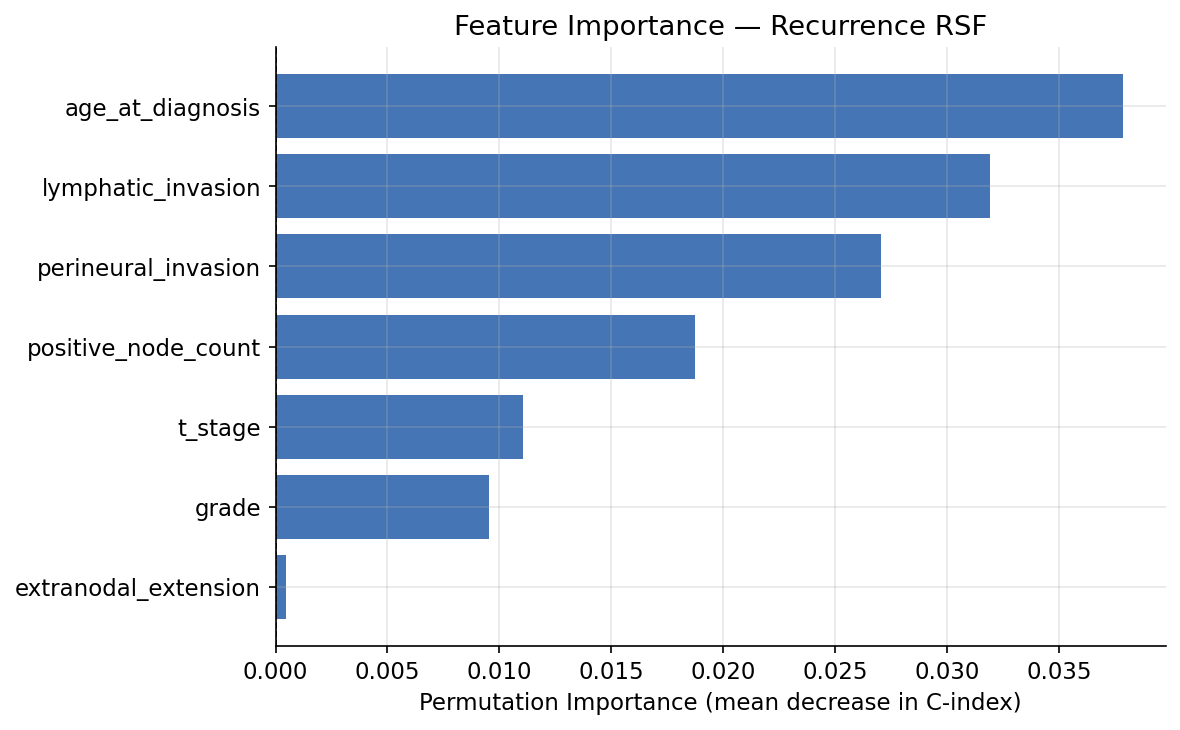


Feature Importance — Recurrence RSF
  Feature                    Importance  Relative %
  -------------------------  ----------  ----------
  age_at_diagnosis               0.0379       27.7%  #############
  lymphatic_invasion             0.0319       23.4%  ###########
  perineural_invasion            0.0271       19.8%  #########
  positive_node_count            0.0188       13.7%  ######
  t_stage                        0.0111        8.1%  ####
  grade                          0.0095        7.0%  ###
  extranodal_extension           0.0005        0.3%  

Overall Survival RSF — Feature Importance


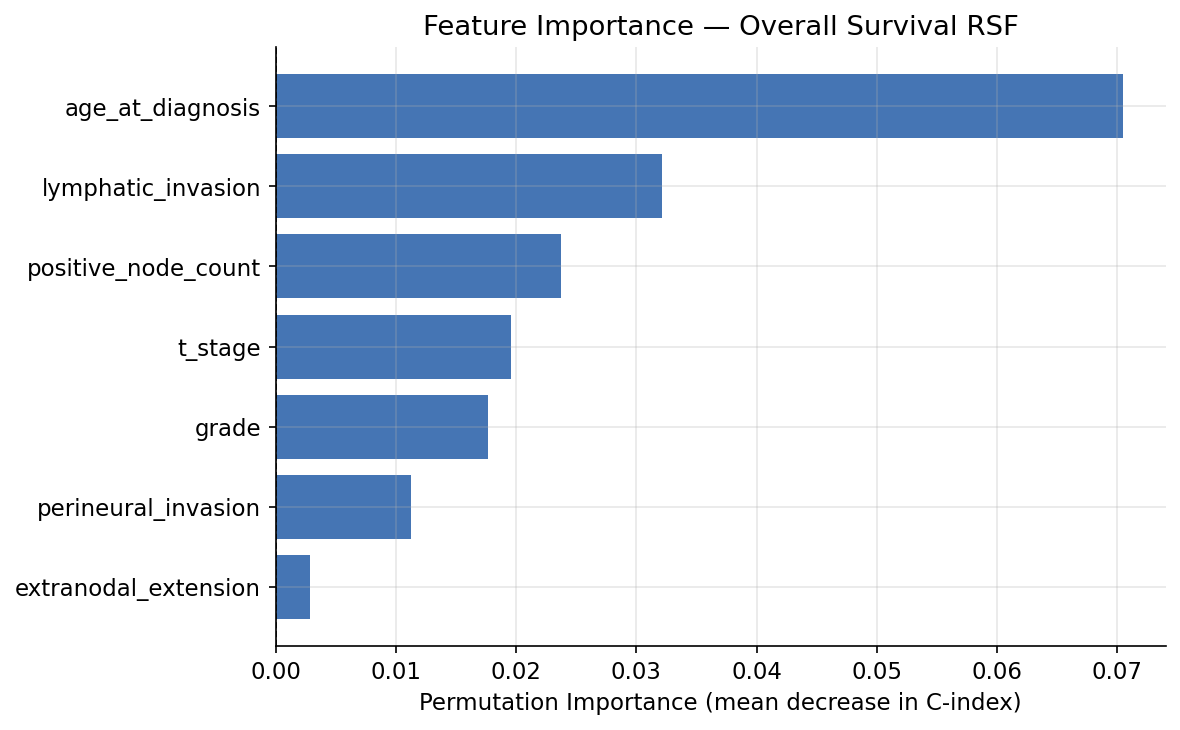


Feature Importance — Overall Survival RSF
  Feature                    Importance  Relative %
  -------------------------  ----------  ----------
  age_at_diagnosis               0.0705       39.7%  ###################
  lymphatic_invasion             0.0322       18.1%  #########
  positive_node_count            0.0238       13.4%  ######
  t_stage                        0.0196       11.0%  #####
  grade                          0.0177        9.9%  ####
  perineural_invasion            0.0112        6.3%  ###
  extranodal_extension           0.0028        1.6%  


In [12]:
def plot_feature_importance(model_obj, feat_names, title):
    imp = model_obj.feature_importance_
    if imp is None or len(imp) == 0:
        print('Feature importance not stored for this model.')
        return

    df_imp = pd.DataFrame({'Feature': feat_names, 'Importance': imp})
    df_imp = df_imp.sort_values('Importance', ascending=True)

    pos_total = df_imp['Importance'].clip(lower=0).sum()

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#d73027' if v < 0 else '#4575b4' for v in df_imp['Importance']]
    ax.barh(df_imp['Feature'], df_imp['Importance'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Permutation Importance (mean decrease in C-index)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    print(f'\n{title}')
    print(f'  {"Feature":<25}  {"Importance":>10}  {"Relative %":>10}')
    print(f'  {"-"*25}  {"-"*10}  {"-"*10}')
    for _, row in df_imp.sort_values('Importance', ascending=False).iterrows():
        rel = row['Importance'] / pos_total * 100 if pos_total > 0 else 0
        bar = '#' * max(0, int(rel / 2))
        print(f'  {row["Feature"]:<25}  {row["Importance"]:>10.4f}  {rel:>9.1f}%  {bar}')


print('Recurrence RSF — Feature Importance')
print('(computed via permutation on training data, 10 repeats)')
feat_names_rr = models['recurrence_rsf']['metadata']['feature_names']
plot_feature_importance(models['recurrence_rsf']['model'], feat_names_rr,
                        'Feature Importance — Recurrence RSF')

print()
print('Overall Survival RSF — Feature Importance')
feat_names_sr = models['survival_rsf']['metadata']['feature_names']
plot_feature_importance(models['survival_rsf']['model'], feat_names_sr,
                        'Feature Importance — Overall Survival RSF')

## 6. Summary

### Results Overview

See tables in Sections 3 and 4 for full results.

### Methodological Notes

**Bootstrap .632 estimator**
Corrects for the optimistic bias inherent in apparent (training-set) metrics.
Formula: `metric_632 = 0.368 × metric_apparent + 0.632 × mean(metric_OOB)`
All three metrics (C-index, IBS, calibration) are evaluated inside a single loop to avoid redundant computation.

**Calibration**
Evaluated at `CAL_T_STAR = 365 days` (1-year horizon) using logistic regression of binary outcome
on `logit(predicted event probability)`. Patients censored before the evaluation time point are excluded.
The intercept (target = 0) and slope (target = 1) characterise weak calibration.

**Why no calibration curve?**
Van Calster et al. (2019) recommend ≥200 events for a reliable calibration curve.
With 25 recurrence and 33 death events, only weak calibration (intercept + slope) is reported.

**Schoenfeld residuals**
Fitted once on the full dataset using `lifelines.CoxPHFitter`. Tests whether the hazard ratio
for each predictor is constant over time. Violations (p < 0.05) should be noted as model limitations.